First I cleaned the data, then engineered features, checked multicollinearity using VIF, selected the important features, scaled the data, built a preprocessing pipeline, and finally saved the preprocessor for inference

# ⚙️ Data Preprocessing

## Project Objective

The objective of this notebook is to prepare the dataset for machine learning by performing data cleaning, feature engineering, preprocessing, feature selection, and building a reusable preprocessing pipeline.

1. Import Libraries

2. Load Dataset

3. Dataset Copy

4. Missing Value Treatment

5. Duplicate Handling

6. Drop Unnecessary Features

7. Feature Engineering

8. Separate Numerical & Categorical Features

9. Encoding

10. Multicollinearity (VIF)

11. Feature Selection

12. Train-Test Split

13. Feature Scaling

14. Build Preprocessing Pipeline

15. Save Preprocessor

16. Final Dataset Summary

17. Key Observations

# 1. Import Required Libraries

In this section, we import all the required libraries for data preprocessing, feature engineering, data splitting, feature scaling, categorical encoding, pipeline creation, and model serialization.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# 2. Load Dataset

Load the dataset into a pandas DataFrame.

In [2]:
df = pd.read_csv("../data/predictive_maintenance.csv")

df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


# 3. Create a Working Copy

Create a copy of the original dataset to preserve the raw data during preprocessing.

In [3]:
df = df.copy()

# 4. Missing Value Treatment

The dataset contains a small percentage of missing values (less than 5%) in a few numerical features.

Instead of removing records, missing values are imputed to preserve the available data.

Median imputation is selected because it is more robust to skewed distributions and outliers than the mean.

In [4]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
vibration_rms,1000,4.159388
pressure_level,924,3.843274
temperature_motor,834,3.468929
current_phase_avg,731,3.040512
rpm,533,2.216954
timestamp,0,0.000000
machine_id,0,0.000000
machine_type,0,0.000000
operating_mode,0,0.000000
hours_since_maintenance,0,0.000000


In [6]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", num_cols)
print("\nCategorical Features:", cat_cols)

Numerical Features: ['machine_id', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'estimated_repair_cost']

Categorical Features: ['timestamp', 'machine_type', 'operating_mode', 'failure_type']


In [7]:
from sklearn.impute import SimpleImputer

median_imputer = SimpleImputer(strategy="median")

df[num_cols] = median_imputer.fit_transform(df[num_cols])

In [8]:
df.isna().sum()

timestamp                  0
machine_id                 0
machine_type               0
vibration_rms              0
temperature_motor          0
current_phase_avg          0
pressure_level             0
rpm                        0
operating_mode             0
hours_since_maintenance    0
ambient_temp               0
rul_hours                  0
failure_within_24h         0
failure_type               0
estimated_repair_cost      0
dtype: int64

# 6. Duplicate Handling

Duplicate records can introduce bias into the model by giving more importance to repeated observations.

In this step, we identify duplicate records and remove them if present to ensure data quality.

In [9]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

Duplicate Records: 0


In [10]:
print("Dataset Shape:", df.shape)

Dataset Shape: (24042, 15)


# 7. Remove Irrelevant Features

Not all features contribute to predictive modeling.

Features such as unique identifiers, timestamps (depending on the use case), or columns with no predictive value are removed to improve model performance and reduce unnecessary complexity.
ect.

In [11]:
df.columns.tolist()


['timestamp',
 'machine_id',
 'machine_type',
 'vibration_rms',
 'temperature_motor',
 'current_phase_avg',
 'pressure_level',
 'rpm',
 'operating_mode',
 'hours_since_maintenance',
 'ambient_temp',
 'rul_hours',
 'failure_within_24h',
 'failure_type',
 'estimated_repair_cost']

In [12]:
len(df.columns)

15

In [13]:
df.drop(columns=["machine_id", "timestamp"], inplace=True)

df.head()

,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0.0,none,0.0
1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0.0,none,0.0
2,CNC,0.71,49.70,6.43,21.3,862.7,idle,274.15,13.6,60.65,0.0,none,0.0
3,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0.0,none,0.0
4,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0.0,none,0.0



Machine ID is a unique identifier and does not contribute to predicting maintenance cost.

The timestamp column is excluded because raw timestamps cannot be directly used by machine learning models. Time-based feature extraction can be performed in advanced versions of the project.

# 8. Feature Engineering

Feature engineering involves creating new features from existing variables to improve the model's ability to capture meaningful patterns.

The following engineered features are created:

- Temperature Difference
- Maintenance Ratio
- Vibration-to-Pressu
- power_indexre Ratio

In [15]:
df["temperature_difference"] = (
    df["temperature_motor"] - df["ambient_temp"]
)

df["maintenance_ratio"] = (
    df["hours_since_maintenance"] /
    (df["rul_hours"] + 1)
)

df["vibration_pressure_ratio"] = (
    df["vibration_rms"] /
    (df["pressure_level"] + 1)
)

df["power_index"] = (
    df["current_phase_avg"] *
    df["pressure_level"]
)

df.head()

,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost,temperature_difference,maintenance_ratio,vibration_pressure_ratio,power_index
0,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0.0,none,0.0,35.61,4.416129,0.032927,120.360
1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0.0,none,0.0,30.38,4.420500,0.030488,125.080
2,CNC,0.71,49.70,6.43,21.3,862.7,idle,274.15,13.6,60.65,0.0,none,0.0,36.10,4.446878,0.031839,136.959
3,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0.0,none,0.0,29.64,4.482449,0.032203,108.254
4,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0.0,none,0.0,30.59,4.495908,0.037931,98.568


In [16]:
len(df.columns)

17

# 9. Separate Numerical and Categorical Features

Machine learning preprocessing techniques differ based on feature types.

In this step, the dataset is divided into numerical and categorical features. This separation enables the application of appropriate preprocessing techniques such as scaling for numerical variables and encoding for categorical variables.

In [17]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical Features ({len(num_cols)}):")
print(num_cols)

print("\n")

print(f"Categorical Features ({len(cat_cols)}):")
print(cat_cols)

Numerical Features (14):
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'estimated_repair_cost', 'temperature_difference', 'maintenance_ratio', 'vibration_pressure_ratio', 'power_index']


Categorical Features (3):
['machine_type', 'operating_mode', 'failure_type']


# 10. Categorical Feature Encoding Strategy

The dataset contains categorical features that cannot be directly used by machine learning algorithms.

Instead of manually encoding the entire dataset, categorical features will be transformed using OneHotEncoder within a preprocessing pipeline. This approach prevents data leakage and ensures consistent preprocessing during both training and inference.

# Multicollinearity Analysis

Multicollinearity occurs when independent variables are highly correlated with one another.

Variance Inflation Factor (VIF) is used to identify highly correlated numerical features. Features with high VIF values may negatively impact regression models and can be considered for removal.

# 11. Feature-to-Feature Correlation Analysis

Correlation analysis is performed to understand the linear relationship between numerical features.

Highly correlated features may indicate redundancy and can lead to multicollinearity issues in regression models.

In [18]:
# Numerical features only
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Correlation matrix
corr_matrix = df[num_cols].corr()

corr_matrix

,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost,temperature_difference,maintenance_ratio,vibration_pressure_ratio,power_index
vibration_rms,1.000000,0.712968,0.821392,0.718398,0.750402,0.016047,-0.003288,-0.056107,0.258481,0.219041,0.694352,-0.084112,0.351796,0.750640
temperature_motor,0.712968,1.000000,0.762627,0.691511,0.611911,0.029718,-0.003563,-0.076825,0.378927,0.406779,0.973649,-0.120042,0.109053,0.704479
current_phase_avg,0.821392,0.762627,1.000000,0.849987,0.781767,-0.001228,-0.005603,-0.024720,0.153219,0.149921,0.743189,-0.072210,-0.010409,0.932481
pressure_level,0.718398,0.691511,0.849987,1.000000,0.604930,0.014772,-0.007976,0.021847,0.012601,0.012656,0.674546,-0.035809,-0.291486,0.934241
rpm,0.750402,0.611911,0.781767,0.604930,1.000000,-0.076247,-0.008013,0.016254,-0.023693,-0.029130,0.597117,-0.071880,0.180934,0.656481
hours_since_maintenance,0.016047,0.029718,-0.001228,0.014772,-0.076247,1.000000,0.010680,-0.306790,0.099519,0.083766,0.026475,0.539160,0.001392,0.015574
ambient_temp,-0.003288,-0.003563,-0.005603,-0.007976,-0.008013,0.010680,1.000000,-0.004021,0.003907,0.001148,-0.231519,0.000928,0.007228,-0.006803
rul_hours,-0.056107,-0.076825,-0.024720,0.021847,0.016254,-0.306790,-0.004021,1.000000,-0.253235,-0.234846,-0.073821,-0.589214,-0.107384,-0.007124
failure_within_24h,0.258481,0.378927,0.153219,0.012601,-0.023693,0.099519,0.003907,-0.253235,1.000000,0.932144,0.367743,-0.109307,0.360225,0.094695
estimated_repair_cost,0.219041,0.406779,0.149921,0.012656,-0.029130,0.083766,0.001148,-0.234846,0.932144,1.000000,0.395467,-0.105130,0.302285,0.093374


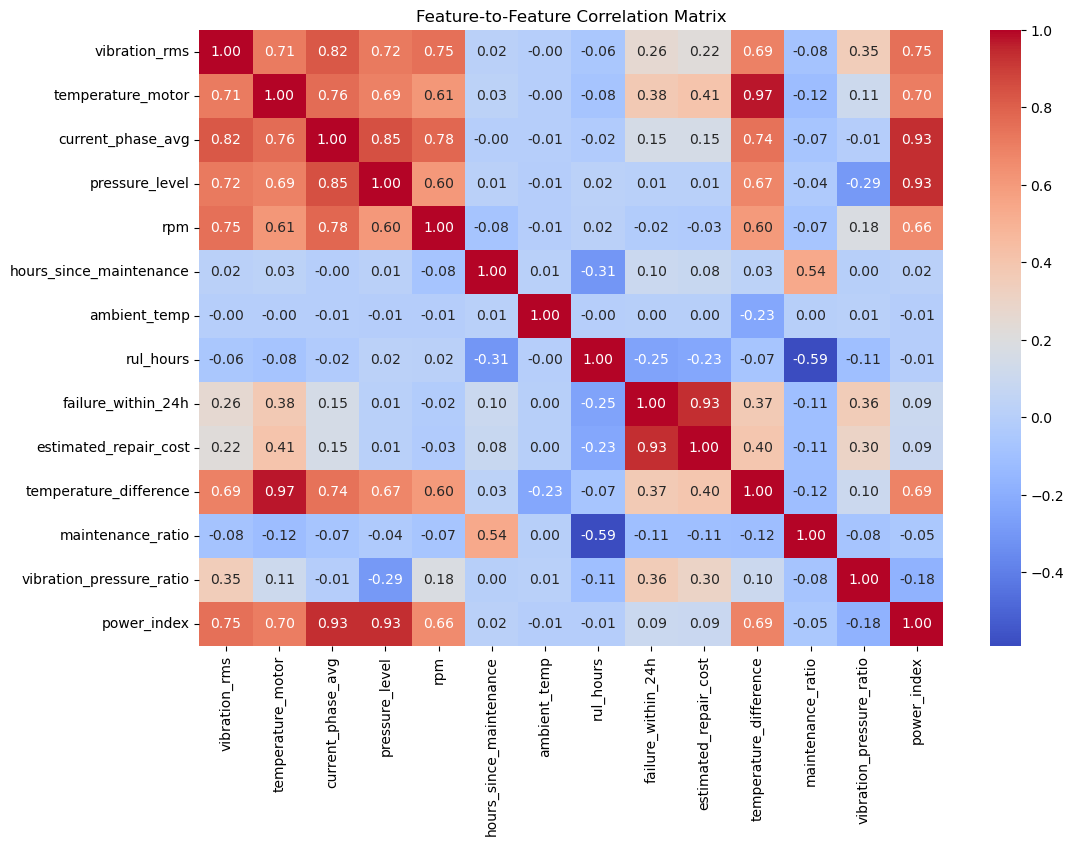

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature-to-Feature Correlation Matrix")
plt.show()

In [20]:
corr_threshold = 0.80

high_corr = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

high_corr.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr = high_corr[
    high_corr["Correlation"].abs() > corr_threshold
]

high_corr.sort_values(
    by="Correlation",
    ascending=False
)

,Feature_1,Feature_2,Correlation
21,temperature_motor,temperature_difference,0.973649
45,pressure_level,power_index,0.934241
35,current_phase_avg,power_index,0.932481
76,failure_within_24h,estimated_repair_cost,0.932144
25,current_phase_avg,pressure_level,0.849987
1,vibration_rms,current_phase_avg,0.821392


# 12. Feature-to-Target Correlation

This analysis measures the relationship between each numerical feature and the target variable.

Features with stronger correlations are generally more informative for predicting the maintenance cost.

In [21]:
target_corr = (
    corr_matrix["estimated_repair_cost"]
    .sort_values(ascending=False)
)

target_corr

estimated_repair_cost       1.000000
failure_within_24h          0.932144
temperature_motor           0.406779
temperature_difference      0.395467
vibration_pressure_ratio    0.302285
vibration_rms               0.219041
current_phase_avg           0.149921
power_index                 0.093374
hours_since_maintenance     0.083766
pressure_level              0.012656
ambient_temp                0.001148
rpm                        -0.029130
maintenance_ratio          -0.105130
rul_hours                  -0.234846
Name: estimated_repair_cost, dtype: float64

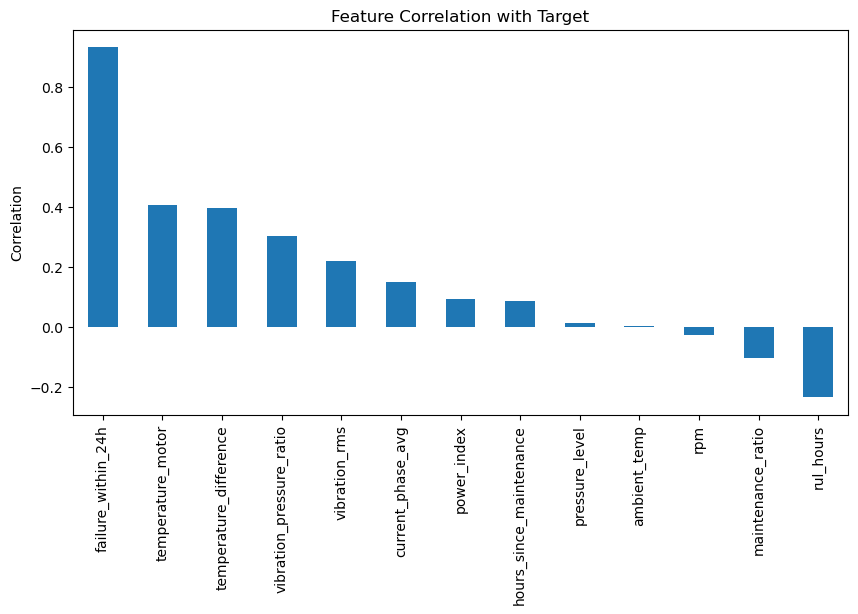

In [22]:
target_corr.drop("estimated_repair_cost").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Feature Correlation with Target")
plt.ylabel("Correlation")
plt.show()

# Key Observations

## Feature-to-Feature Correlation

The correlation analysis revealed several highly correlated feature pairs:

- `temperature_motor` and `temperature_difference` showed a very strong positive correlation (0.97). This is expected because the engineered feature `temperature_difference` is derived from `temperature_motor` and `ambient_temp`.

- `power_index` showed a very high correlation with both `current_phase_avg` (0.93) and `pressure_level` (0.93). Since `power_index` is an engineered feature calculated using these variables, a strong correlation is expected.

- `current_phase_avg` and `pressure_level` also exhibited a high positive correlation (0.85), indicating that both variables may contain overlapping information.

- `vibration_rms` and `current_phase_avg` showed a moderately high positive correlation (0.82), suggesting a possible relationship between machine vibration and electrical load.

---

## Feature-to-Target Correlation

The relationship between each numerical feature and the target variable (`estimated_repair_cost`) was analyzed.

### Strong Correlation

- `failure_within_24h` showed the strongest positive correlation (0.93) with the target variable. This feature requires further investigation to determine whether it introduces data leakage before including it in model training.

### Moderate Correlation

The following features showed moderate positive relationships with the target:

- `temperature_motor`
- `temperature_difference`
- `vibration_pressure_ratio`
- `vibration_rms`

These features are expected to contribute positively to predicting maintenance cost.

### Weak Correlation

The following features showed relatively weak relationships with the target:

- `current_phase_avg`
- `power_index`
- `hours_since_maintenance`
- `pressure_level`
- `ambient_temp`
- `rpm`
- `maintenance_ratio`

A weak correlation does not necessarily mean that a feature is unimportant. Some machine learning algorithms can capture non-linear relationships that are not reflected in Pearson correlation.

### Negative Correlation

- `rul_hours` showed a moderate negative correlation (-0.23), indicating that machines with fewer remaining useful life hours generally tend to have higher repair costs.

---

## Next Step

Correlation analysis alone is not sufficient for feature selection.

The next step is to perform **Multicollinearity Analysis using Variance Inflation Factor (VIF)** to identify redundant features before finalizing the feature set.

# 13. Multicollinearity Analysis (VIF)

Variance Inflation Factor (VIF) was calculated to identify multicollinearity among the numerical features.

A high VIF value indicates that a feature can be explained by other independent features, suggesting redundant information.

The commonly used interpretation is:

- VIF < 5 : Low multicollinearity
- VIF 5–10 : Moderate multicollinearity
- VIF > 10 : High multicollinearity

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
X_vif = df[num_cols].drop(columns=["estimated_repair_cost"])

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values(by="VIF", ascending=False)

vif

,Feature,VIF
1,temperature_motor,inf
6,ambient_temp,inf
9,temperature_difference,inf
2,current_phase_avg,57.276817
3,pressure_level,47.324068
12,power_index,33.843308
0,vibration_rms,26.365872
11,vibration_pressure_ratio,19.535262
4,rpm,9.729188
7,rul_hours,3.622059


## Key Observations

### 1. Infinite VIF Values

The following features produced infinite VIF values:

- temperature_motor
- ambient_temp
- temperature_difference

This occurred because `temperature_difference` is directly calculated using:

temperature_difference = temperature_motor - ambient_temp

As a result, these features exhibit perfect linear dependency, leading to infinite VIF values.

---

### 2. Very High Multicollinearity

The following features showed severe multicollinearity:

| Feature | VIF |
|---------|----:|
| current_phase_avg | 57.28 |
| pressure_level | 47.32 |
| power_index | 33.84 |
| vibration_rms | 26.37 |
| vibration_pressure_ratio | 19.54 |

These variables contain substantial overlapping information and require further evaluation before model training.

---

### 3. Moderate Multicollinearity

- rpm (VIF = 9.73)

This feature shows moderate multicollinearity and will be reviewed together with its relationship to the target variable.

---

### 4. Acceptable Multicollinearity

The following features have acceptable VIF values:

- failure_within_24h
- maintenance_ratio
- hours_since_maintenance
- rul_hours

These features do not exhibit significant multicollinearity.

# 14. Feature Selection

Feature selection is performed iteratively based on three criteria:

1. Feature-to-Feature Correlation
2. Feature-to-Target Correlation
3. Variance Inflation Factor (VIF)

Instead of removing all highly correlated features at once, features are removed one at a time, and VIF is recalculated after each iteration. This approach helps retain the most informative features while reducing multicollinearity.ty (VIF)

In [25]:
df.drop(columns=["power_index"], inplace=True)

print("power_index removed successfully.")

power_index removed successfully.


In [26]:
df.drop(columns=["temperature_difference"], inplace=True)

print("temperature_difference removed successfully.")

temperature_difference removed successfully.


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])

X_vif = X_vif.select_dtypes(include=["int64","float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,temperature_motor,42.846964
3,pressure_level,30.216207
2,current_phase_avg,28.432715
0,vibration_rms,26.314009
10,vibration_pressure_ratio,19.514100
6,ambient_temp,15.274556
4,rpm,9.509945
7,rul_hours,3.578355
5,hours_since_maintenance,3.464694
9,maintenance_ratio,3.039389


## Feature Selection - Iteration 2

The first iteration reduced multicollinearity by removing redundant engineered features.

After recalculating VIF, `vibration_pressure_ratio` still exhibited a high VIF value (19.51). Since this feature is derived from `vibration_rms` and `pressure_level`, it introduces redundant information.

Although the feature has a moderate correlation with the target variable, the original sensor measurements are retained because they are more interpretable and preserve the original machine information.

Therefore, `vibration_pressure_ratio` is removed and VIF is recalculated.

In [28]:
df.drop(columns=["vibration_pressure_ratio"], inplace=True)

print("vibration_pressure_ratio removed successfully.")

vibration_pressure_ratio removed successfully.


In [29]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])
X_vif = X_vif.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif = vif.sort_values(by="VIF", ascending=False)

vif

,Feature,VIF
1,temperature_motor,31.668981
2,current_phase_avg,28.121414
3,pressure_level,15.323900
6,ambient_temp,13.681530
0,vibration_rms,13.430527
4,rpm,9.502831
7,rul_hours,3.516563
5,hours_since_maintenance,3.464209
9,maintenance_ratio,3.009624
8,failure_within_24h,2.185073


## Feature Selection - Iteration 3

In [30]:
df.drop(columns=["ambient_temp"], inplace=True)

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])
X_vif = X_vif.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
2,current_phase_avg,28.081160
1,temperature_motor,15.720447
3,pressure_level,15.011233
0,vibration_rms,13.429696
4,rpm,9.416238
5,hours_since_maintenance,3.458719
6,rul_hours,3.311925
8,maintenance_ratio,2.902351
7,failure_within_24h,2.141701


## Feature Selection - Iteration 4

In [32]:
df.drop(columns=["pressure_level"], inplace=True)

print("pressure_level removed successfully.")

pressure_level removed successfully.


In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])
X_vif = X_vif.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
2,current_phase_avg,16.203916
1,temperature_motor,15.195399
0,vibration_rms,12.711470
3,rpm,8.378078
4,hours_since_maintenance,3.456903
5,rul_hours,3.309095
7,maintenance_ratio,2.902078
6,failure_within_24h,1.881920


## Feature Selection - Iteration 5

In [34]:
df.drop(columns=["current_phase_avg"], inplace=True)

print("current_phase_avg removed successfully.")

current_phase_avg removed successfully.


In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])
X_vif = X_vif.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
1,temperature_motor,12.802349
0,vibration_rms,10.147914
2,rpm,7.175634
3,hours_since_maintenance,3.456579
4,rul_hours,3.284972
6,maintenance_ratio,2.893469
5,failure_within_24h,1.873823


## Feature Selection - Iteration 6

In [36]:
df.drop(columns=["vibration_rms"], inplace=True)

print("vibration_rms removed successfully.")

vibration_rms removed successfully.


In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df.drop(columns=["estimated_repair_cost"])
X_vif = X_vif.select_dtypes(include=["int64", "float64"])

vif = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
0,temperature_motor,11.076197
1,rpm,4.083337
2,hours_since_maintenance,3.447129
3,rul_hours,3.266678
5,maintenance_ratio,2.877444
4,failure_within_24h,1.762643


## Removal of Target-Specific Features

The dataset contains multiple prediction targets, including:

- `failure_within_24h` (Binary Classification)
- `failure_type` (Multi-class Classification)
- `rul_hours` (Regression)
- `estimated_repair_cost` (Regression)

The objective of this project is to predict **estimated repair cost**.

The feature `failure_within_24h` was designed as a separate prediction target for failure forecasting. In a real-world production environment, this information would not be available at the time of estimating repair cost because it represents a future event.

Using this feature as an input could introduce **data leakage**, allowing the model to learn information that would not be available during inference.

Therefore, `failure_within_24h` was removed from the feature set.

The `rul_hours` feature was retained because it represents the machine's remaining useful life and is considered an operational indicator that may be available through monitoring systems. Its impact on model performance will be evaluated during model training.

In [38]:
df.drop(columns=["failure_within_24h"], inplace=True)

print("failure_within_24h removed successfully.")

failure_within_24h removed successfully.


In [39]:
len(df.columns)

9

# Final Feature Selection Summary


The dataset contains multiple prediction targets. Since my objective was repair cost estimation, I removed failure_within_24h because it is itself a target for a different prediction task. Using it as an input feature could introduce data leakage, as that information would not be available when estimating repair cost in a production environment.

Feature selection was performed iteratively using:

- Feature-to-Feature Correlation
- Feature-to-Target Correlation
- Variance Inflation Factor (VIF)
- Domain Knowledge

During each iteration, the feature with the highest redundancy and the least predictive contribution was removed. After every removal, VIF values were recalculated.

The iterative process stopped when all remaining features were considered meaningful for prediction and further feature removal could result in the loss of important business information.

Although `temperature_motor` retained a VIF slightly above the recommended threshold, it was preserved because:

- It is an original machine sensor measurement.
- It has one of the strongest correlations with the target variable.
- Removing it would likely reduce the predictive capability of the model.

Therefore, the remaining feature set was finalized.

In [45]:
df.head()

,machine_type,temperature_motor,rpm,operating_mode,hours_since_maintenance,rul_hours,failure_type,estimated_repair_cost,maintenance_ratio
0,CNC,49.51,860.9,idle,273.80,61.00,none,0.0,4.416129
1,CNC,40.58,899.6,idle,273.85,60.95,none,0.0,4.420500
2,CNC,49.70,862.7,idle,274.15,60.65,none,0.0,4.446878
3,CNC,43.04,870.4,idle,274.55,60.25,none,0.0,4.482449
4,CNC,41.39,881.9,idle,274.70,60.10,none,0.0,4.495908


# 13. Separate Features and Target

Before training a machine learning model, the dataset is divided into:

- Features (X): Independent variables used for prediction.
- Target (y): Dependent variable that the model learns to predict.

The target variable for this project is `estimated_repair_cost`.

In [40]:
# Features
X = df.drop(columns=["estimated_repair_cost"])

# Target
y = df["estimated_repair_cost"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (24042, 8)
Target Shape  : (24042,)


# 14. Train-Test Split

The dataset is divided into training and testing subsets.

- Training Set (80%)
  Used to train the machine learning model and fit the preprocessing pipeline.

- Testing Set (20%)
  Used only for evaluating the model on unseen data.

The split is performed before preprocessing to prevent data leakage.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (19233, 8)
X_test  : (4809, 8)
y_train : (19233,)
y_test  : (4809,)


In [42]:
print(X_train.shape)
print(X_test.shape)

(19233, 8)
(4809, 8)


# 15. Identify Numerical and Categorical Features

The preprocessing steps differ for numerical and categorical variables.

Therefore, the feature columns are identified separately before constructing the preprocessing pipeline.

In [43]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(num_cols)

print("\nCategorical Features")
print(cat_cols)

Numerical Features
['temperature_motor', 'rpm', 'hours_since_maintenance', 'rul_hours', 'maintenance_ratio']

Categorical Features
['machine_type', 'operating_mode', 'failure_type']


# 16. Numerical Preprocessing Pipeline

The numerical pipeline performs:

- Missing value imputation using the median strategy.
- Feature scaling using StandardScaler.

Median imputation is robust to outliers, while StandardScaler standardizes numerical features for algorithms sensitive to feature scales.

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

# 17. Categorical Preprocessing Pipeline

Categorical features require preprocessing before they can be used by machine learning algorithms.

The categorical pipeline performs:

- Missing value imputation using the most frequent value.
- One-Hot Encoding to convert categorical variables into numerical format.

The `handle_unknown='ignore'` parameter ensures that unseen categories appearing during prediction do not cause errors.

In [46]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

cat_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

# 18. Build Column Transformer

The ColumnTransformer combines the numerical and categorical preprocessing pipelines.

- Numerical features are processed using the numerical pipeline.
- Categorical features are processed using the categorical pipeline.

This ensures that each feature type receives the appropriate preprocessing while keeping the workflow organized and reusable.

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("numerical", num_pipeline, num_cols),
    ("categorical", cat_pipeline, cat_cols)
])

preprocessor

# 19. Fit the Preprocessing Pipeline

The preprocessing pipeline is fitted only on the training dataset.

This prevents data leakage by ensuring that preprocessing parameters such as scaling statistics and encoding mappings are learned exclusively from the training data.

In [ ]:
preprocessor.fit(X_train)

print("Preprocessor fitted successfully.")

# 20. Transform the Dataset

After fitting the preprocessing pipeline on the training data, the same transformations are applied to both the training and testing datasets.

This guarantees that both datasets are processed consistently.

In [ ]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape :", X_train_processed.shape)
print("Processed Testing Shape  :", X_test_processed.shape)

# 21. Save the Preprocessor

The fitted preprocessing pipeline is saved to disk using Joblib.

Saving the preprocessor ensures that the exact same preprocessing steps are applied during model training and future predictions in the production environment.

In [ ]:
import joblib
import os

os.makedirs("./model", exist_ok=True)

joblib.dump(preprocessor, "./model/preprocessor.pkl")

print("Preprocessor saved successfully.")

# 22. Save Processed Dataset

The cleaned dataset after preprocessing and feature selection is saved for model training.

This ensures that the same cleaned dataset is used consistently across training, evaluation, and deployment notebooks.

In [ ]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/processed_data.csv", index=False)

print("Processed dataset saved successfully.")

# Key Observations

- Missing values handled successfully.
- Duplicate records removed.
- Irrelevant features dropped.
- New features engineered.
- Categorical features encoded.
- Multicollinearity reduced.
- Dataset split into training and testing sets.
- Features scaled successfully.
- Preprocessing pipeline created.